# 5.3 전이 학습

- 큰데이터셋 확보에 많은 돈과 시간 필요 --(해결)--> 전이학습 이용
- 전이학습 : 아주 큰 데이터셋을 써서 훈련된 모델의 가중치를 가져와 우리가 해결하려는 과제에 맞게 보정해서 사용하는 것
- 방법: 특성추출 & 미세 조정 기법

## 5.3.1 특성 추출 기법
- 특성 추출 : 사전 훈련된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만든거임.
- 합성곱층과 데이터 분류기로 두부분으로 구성됨.
- torchvision.transform : 이미지 데이터 변환-> 모델의 입력으로 사용할 수 있게 변환해줌
    - resize: 이미지의 크기 조정
    - RandomsizedCrop: 이미지를 랜덤한 크기 및 비율로 자름
    - RandomHorizontalFlip : 이미지를 랜덤하게 수평으로 뒤집음
    - ToTensor: 이미지 데이터 -> 텐서로 변환

- iter() : 전달된 데이터의 반복자를 꺼내 반환
- next() : 그 반복자가 다음에 필요한 출력해야할 요소를 반환
- 모델의 일부를 고정하고 나머지를 학습하고자 할때 requires_grad=False로 설정
- 완전 연결층은 학습을 하도록 설정함.
- torch.max : 주어진 텐서 배열의 최대값이 들어있는 index를 반환
- preds.eq(labels) : preds 배열과 labels가 일치하는지 검사하는 용도로 사용
- tensor.clone(): 기존 텐서의 내용을 복사한 텐서를 생성함
- detach(): 기존 텐서에서 기울기가 전파되지 않은 텐서
- clip(): 입력값이 주어진 범위를 벗어날때 입력값을 특정 범위로 제한시키기 위해 사용

## 5.3.2 미세 조정 기법
- 특성 추출 기법 + 사전 훈련된 모델과 합성곱층, 데이터 분류기의 가중치를 업데이트하여 훈련시키는 방식
- 데이터 셋 큼+ 유사성 작 : 모델 전체 재학습
- 데이터 셋 큼+ 유사성 큼 : 합성곱층의 뒷부분과 데이터 분류기를 학습
- 데이터 셋 작+ 유사성 작 : 어디까지 학습해야할지 설정
- 데이터 셋 작 +유사성 큼: 데이터 분류기만 학습

In [1]:
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data_path='/content/drive/MyDrive/ESAA/OB/hw/catanddog/train'

transform=transforms.Compose(
    [transforms.Resize([256,256]),
     transforms.RandomResizedCrop(224),
     transforms.RandomHorizontalFlip(),
     transforms.ToTensor()

    ]
)

train_dataset=torchvision.datasets.ImageFolder(data_path, transform=transform)
train_loader=torch.utils.data.DataLoader(train_dataset, batch_size=32, num_workers=8, shuffle=True)

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


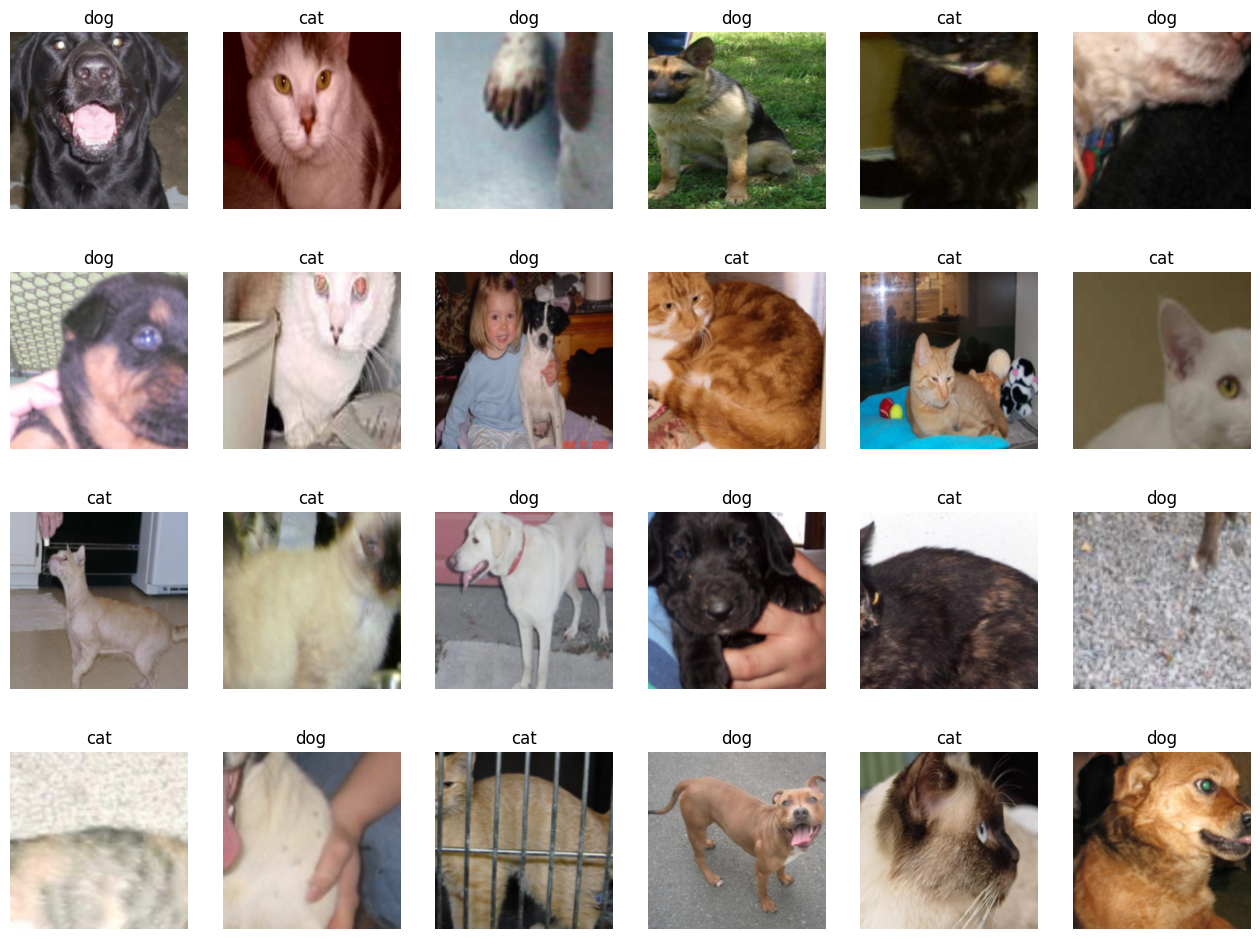

In [5]:
import numpy as np
samples, labels = next(iter(train_loader))
classes={0:'cat', 1:'dog'}
fig=plt.figure(figsize=(16,24))
for i in range(24):
  a=fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')
  plt.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

In [6]:
resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:

def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

set_parameter_requires_grad(resnet18)

In [8]:
resnet18.fc = nn.Linear(512,2)

In [9]:
for name, param in resnet18.named_parameters():
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[-0.0077,  0.0296,  0.0037,  ...,  0.0124, -0.0146, -0.0072],
        [ 0.0378, -0.0203, -0.0422,  ..., -0.0287,  0.0011, -0.0300]])
fc.bias tensor([0.0073, 0.0028])


In [10]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
  param.requires_grad = False

model.fc = torch.nn.Linear(512,2)

for param in model.fc.parameters():
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13,
                is_train=True):
  since = time.time()
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-'*10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders:
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      running_corrects += torch.sum(preds==labels.data)

    epoch_loss = running_loss/len(dataloaders.dataset)
    epoch_acc = running_corrects.double()/len(dataloaders.dataset)

    print('Loss:{:.4f} Acc:{:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(),
               os.path.join('/content/drive/MyDrive/ESAA/OB/hw/catanddog''{0:0=2d}.pth'.format(epoch)))
    print()

  time_elapsed = time.time()
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60,
                                                      time_elapsed % 60))
  print('Best ACC: {:.4f}'.format(best_acc))
  return acc_history, loss_history

In [12]:
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param)
    print("/t", name)

optimizer = optim.Adam(params_to_update)

/t fc.weight
/t fc.bias


In [13]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion=nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist=train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss:0.0226 Acc:0.5896

Epoch 1/12
----------
Loss:0.0138 Acc:0.8078

Epoch 2/12
----------
Loss:0.0120 Acc:0.8883

Epoch 3/12
----------
Loss:0.0093 Acc:0.9143

Epoch 4/12
----------
Loss:0.0092 Acc:0.9013

Epoch 5/12
----------
Loss:0.0092 Acc:0.8909

Epoch 6/12
----------
Loss:0.0084 Acc:0.9195

Epoch 7/12
----------
Loss:0.0080 Acc:0.9169

Epoch 8/12
----------
Loss:0.0089 Acc:0.9195

Epoch 9/12
----------
Loss:0.0097 Acc:0.8935

Epoch 10/12
----------
Loss:0.0071 Acc:0.9273

Epoch 11/12
----------
Loss:0.0074 Acc:0.9117

Epoch 12/12
----------
Loss:0.0086 Acc:0.9221

Training complete in 29398411m 52s
Best ACC: 0.9273


In [14]:
test_path='/content/drive/MyDrive/ESAA/OB/hw/catanddog/test'

transform = transforms.Compose(
                [
                    transforms.Resize(224),
                    transforms.CenterCrop(224),
                    transforms.ToTensor(),
                ])
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


In [15]:
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('./content/drive/MyDrive/ESAA/OB/hw/catanddog/' + '*.pth')
    saved_models.sort()
    print('saved_model', saved_models)

    for model_path in saved_models:
        print('Loading model', model_path)

        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                outputs = model(inputs)

            _, preds = torch.max(outputs.data, 1)
            running_corrects += preds.eq(labels).int().sum()

        epoch_acc = running_corrects.double() / len(dataloaders.dataset)
        print('Acc: {:.4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        print()

    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))

    return acc_history

In [16]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model []
Validation complete in 0m 0s
Best Acc: 0.000000


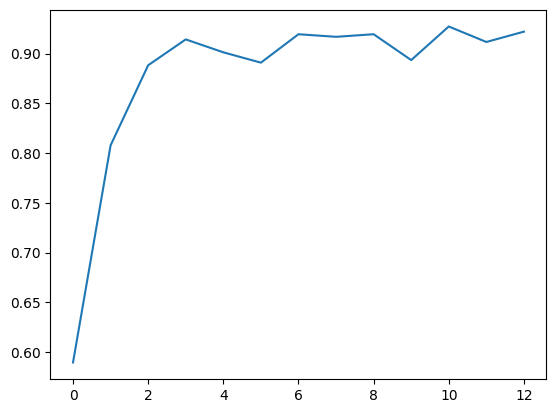

In [17]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

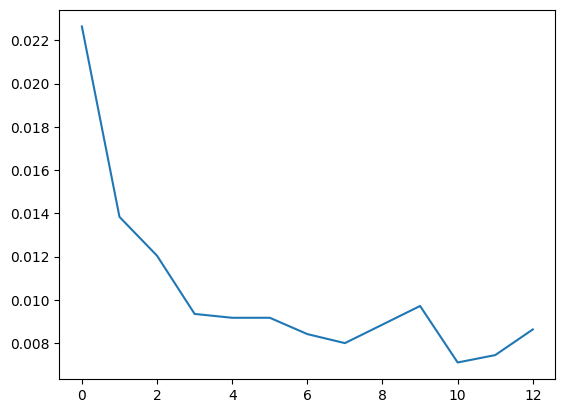

In [18]:
plt.plot(train_loss_hist)
plt.show()

In [19]:
def im_convert(tensor):
    image=tensor.clone().detach().numpy()
    image=image.transpose(1,2,0)
    image=image*(np.array((0.5,0.5,0.5))+np.array((0.5,0.5,0.5)))
    image=image.clip(0,1)
    return image

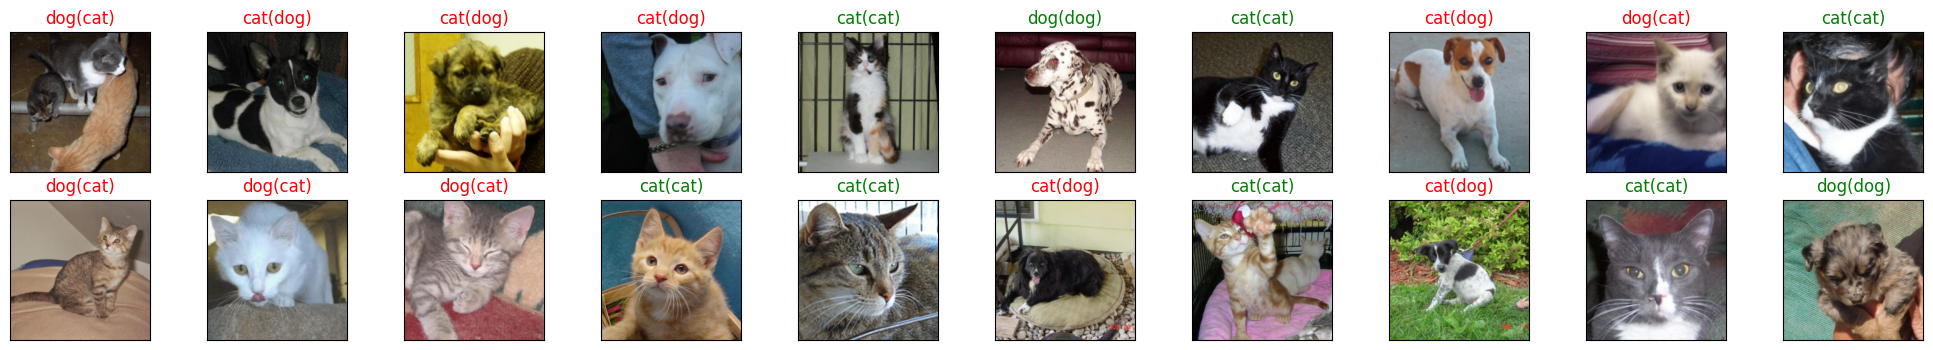

<Figure size 640x480 with 0 Axes>

In [20]:
classes = {0:'cat', 1:'dog'}

dataiter=iter(test_loader)
images,labels= next(dataiter)
output=model(images)
_,preds=torch.max(output,1)

fig=plt.figure(figsize=(25,4))
for idx in np.arange(20):
    ax=fig.add_subplot(2,10,idx+1,xticks=[],yticks=[])
    plt.imshow(im_convert(images[idx]))
    a.set_title(classes[labels[i].item()])
    ax.set_title("{}({})".format(str(classes[preds[idx].item()]),str(classes[labels[idx].item()])),color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)